<a href="https://colab.research.google.com/github/souldrive7/base/blob/main/6025131_%E5%BE%8C%E8%97%A4%E6%99%83%E9%83%81_%E5%BC%B7%E5%8C%96%E5%AD%A6%E7%BF%92%E3%83%BB%E8%BB%A2%E7%A7%BB%E5%AD%A6%E7%BF%92_%E7%94%B0%E4%B8%AD%E5%85%88%E7%94%9F_%E3%83%AC%E3%83%9D%E3%83%BC%E3%83%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#課題レポート：強化学習・転移学習理論（田中先生）
####提出日：2026年1月19日
####学籍番号：6025131
####氏名：後藤 晃郁

##1. 理論的背景と実装方針

本レポートでは、リサイクルロボット問題について課題4の方策勾配法を実装する。

方策勾配法は、方策関数 $\pi_\theta(a|s)$ をニューラルネットワークで近似し、収益の期待値を最大化するようにパラメータ $\theta$ を勾配法で直接更新する手法である。

###**アルゴリズムの要点**

講義資料のヒントに基づき、以下の工夫を取り入れた実装を行う。

1.  **ネットワーク構造**:

    隠れ層を1層（32ユニット）とし、出力層には **Softmax関数** を用いて確率分布を出力する

2.  **アドバンテージ関数の近似 (A3C論文の手法)**:

    方策勾配定理における更新式 $\nabla_\theta J(\theta) = \mathbb{E}[\nabla_\theta \log \pi(a|s) A(s,a)]$ に対し、アドバンテージ $A(s,a)$ を計算するためのCritic（価値関数）を別途学習するのはコストが高い。

    そこで本実装では、A3Cの論文と同様に、モンテカルロ法で計算した収益 $G_t$ をバッチ内で「平均0、標準偏差1」に標準化したものをアドバンテージの代用として用いる。これにより分散を低減し、学習を安定させる。

3.  **損失関数 (Loss Function)**:

    パラメータ更新は、以下のCross Entropy型 Lossを最小化することで行う。
    $$Loss(\theta) = - \sum_{t} \log \pi_\theta(a_t|s_t) \cdot \hat{A}_t$$
    （ここで $\hat{A}_t$ は標準化された収益）

In [ ]:
# ------------------------------------------------------------------------------
# 1. 再現性の確保や準備
# ------------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import random

def set_seed(seed=510):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)

## 2. 環境の定義 (Environment)

リサイクルロボット問題をエピソードタスクとして定義する。

状態空間は $\mathcal{S}=\{High, Low\}$、行動空間は $\mathcal{A}=\{Wait, Search, Recharge\}$ である。

**状態遷移と報酬の設計:**
* **High状態**:
    * Search: 確率 $\alpha$ で成功（報酬2）、確率 $1-\alpha$ でLowへ遷移。
    * Recharge: High状態での充電は無効な行動とみなし、状態遷移せず報酬を0とする（Waitの報酬1より低く設定することで、選択しないよう学習させる）。
* **Low状態**:
    * Search: 確率 $\beta$ で成功（報酬2）、確率 $1-\beta$ でガス欠（報酬-3、Highへ強制遷移）。
    * Recharge: 確実にHighへ遷移（報酬0）。

In [ ]:
# ------------------------------------------------------------------------------
# 2. 環境の定義 (Environment)
# ------------------------------------------------------------------------------
class RecycleRobotEnv:
    """
    リサイクルロボット環境 (エピソードタスク版)
    状態: 0=High, 1=Low
    行動: 0=Wait, 1=Search, 2=Recharge
    """
    def __init__(self):
        # パラメータ設定
        self.alpha = 0.5  # Highでの探索成功確率
        self.beta = 0.5   # Lowでの探索成功確率

        # 報酬設定
        self.r_wait = 1.0
        self.r_search = 2.0
        self.r_rescue = -3.0
        self.r_recharge = 0.0

        # エピソードタスクとして定義するため、最大ステップ数を設ける
        self.max_steps = 100
        self.current_step = 0
        self.state = 0 # 初期状態 (0: High)

    def reset(self):
        self.state = 0
        self.current_step = 0
        return self.state

    def step(self, action):
        """
        return: next_state, reward, done
        """
        self.current_step += 1
        reward = 0
        next_state = self.state

        # --- 状態: High (0) ---
        if self.state == 0:
            if action == 0: # Wait
                reward = self.r_wait
                next_state = 0
            elif action == 1: # Search
                if np.random.rand() < self.alpha:
                    reward = self.r_search
                    next_state = 0
                else:
                    reward = self.r_search
                    next_state = 1
            elif action == 2: # Recharge
                # High状態でのRechargeは無効行動とする(報酬0)
                reward = 0.0
                next_state = 0

        # --- 状態: Low (1) ---
        elif self.state == 1:
            if action == 0: # Wait
                reward = self.r_wait
                next_state = 1
            elif action == 1: # Search
                if np.random.rand() < self.beta:
                    reward = self.r_search
                    next_state = 1
                else:
                    reward = self.r_rescue
                    next_state = 0
            elif action == 2: # Recharge
                reward = self.r_recharge
                next_state = 0 # 確実にHighへ

        self.state = next_state
        done = (self.current_step >= self.max_steps)

        return next_state, reward, done

## 3. 方策ネットワーク (Policy Network)

課題のヒント「隠れ層が1層か2層でそれぞれ数十ユニット」に準拠し、以下の構成とする。

* 入力層: 状態のOne-hotベクトル (次元数2)
* 隠れ層: 全結合層 (32ユニット) + ReLU活性化関数
* 出力層: 全結合層 (3ユニット) + Softmax関数

In [ ]:
# ------------------------------------------------------------------------------
# 3. 方策ネットワーク (Policy Network)
# ------------------------------------------------------------------------------
class PolicyNetwork(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super(PolicyNetwork, self).__init__()
        # 隠れ層: 1層で32ユニット
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        #出力はsoftmax型
        x = F.softmax(self.fc2(x), dim=-1)
        return x

    def get_action(self, state):
        state_one_hot = torch.zeros(2)
        state_one_hot[state] = 1.0

        probs = self.forward(state_one_hot)

        dist = torch.distributions.Categorical(probs)
        action = dist.sample()

        return action.item(), dist.log_prob(action)

## 4. REINFORCEアルゴリズムの実装

学習ループの実装を行う。
収益の標準化は、PyTorchのテンソル演算を用いて以下のように実装する。

In [ ]:
# 収益の計算 (Monte Carlo)
returns = []
G = 0
for r in reversed(rewards):
    G = r + GAMMA * G
    returns.insert(0, G)
returns = torch.tensor(returns)

# 標準化 (平均0, 標準偏差1)
returns = (returns - returns.mean()) / (returns.std() + 1e-9)

この標準化されたreturns（収益）を重みとして、対数確率 log_prob との積の総和（の負数）をLossとし、誤差逆伝播を行う。

In [ ]:
# ------------------------------------------------------------------------------
# 4. 学習ループ (REINFORCE Algorithm)
# ------------------------------------------------------------------------------
def train():
    # ハイパーパラメータ
    GAMMA = 0.9       # 割引率
    LR = 0.01         # 学習率
    HIDDEN_DIM = 32   # 隠れ層ユニット数
    NUM_EPISODES = 2000

    env = RecycleRobotEnv()
    policy_net = PolicyNetwork(input_dim=2, hidden_dim=HIDDEN_DIM, output_dim=3)
    optimizer = optim.Adam(policy_net.parameters(), lr=LR)

    total_rewards_history = []

    print(f"Training Start (Episodes: {NUM_EPISODES})...")

    for episode in range(NUM_EPISODES):
        state = env.reset()
        log_probs = [] # log π(at|st)
        rewards = []   # 即時報酬 rt

        while True:
            action, log_prob = policy_net.get_action(state)
            next_state, reward, done = env.step(action)

            log_probs.append(log_prob)
            rewards.append(reward)
            state = next_state

            if done:
                break

        total_rewards_history.append(sum(rewards))

        # --- 収益 Gt の計算 (Monte Carlo) ---
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + GAMMA * G
            returns.insert(0, G)
        returns = torch.tensor(returns)

        # --- 平均0, 標準偏差1に標準化 ---
        if len(returns) > 1:
            returns = (returns - returns.mean()) / (returns.std() + 1e-9)
        else:
            returns = returns - returns.mean()

        # --- パラメータ更新 (Cross Entropy型 Loss) ---
        # Loss = - Σ log π(at|st) * A(st, at)
        loss = 0
        for log_prob, A_val in zip(log_probs, returns):
            loss += -log_prob * A_val

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (episode + 1) % 200 == 0:
            avg = np.mean(total_rewards_history[-100:])
            print(f"Episode {episode+1:>4}, Avg Reward: {avg:.2f}")

    print("Training Finished.")
    return policy_net, total_rewards_history

## 5. 結果の確認と考察

学習曲線（移動平均）および学習済み方策の出力確率を確認する。

**考察のポイント**:
* **High状態**:

リスクがあっても高い報酬が期待できる「Search」が選択されているか。

* **Low状態**:

「Search」によるガス欠（-3点）のリスクを避け、かつ「Wait」（1点）で留まるよりも、一度「Recharge」（0点）してHigh状態に戻る（将来のSearch成功を狙う）戦略が取られているか。
* 割引率

$\gamma=0.9$ と比較的高いため、長期的視野での収益最大化（Recharge戦略）が合理的となる。

Training Start (Episodes: 2000)...
Episode  200, Avg Reward: 133.65
Episode  400, Avg Reward: 132.30
Episode  600, Avg Reward: 133.54
Episode  800, Avg Reward: 133.81
Episode 1000, Avg Reward: 133.92
Episode 1200, Avg Reward: 133.43
Episode 1400, Avg Reward: 134.02
Episode 1600, Avg Reward: 133.40
Episode 1800, Avg Reward: 133.76
Episode 2000, Avg Reward: 133.85
Training Finished.


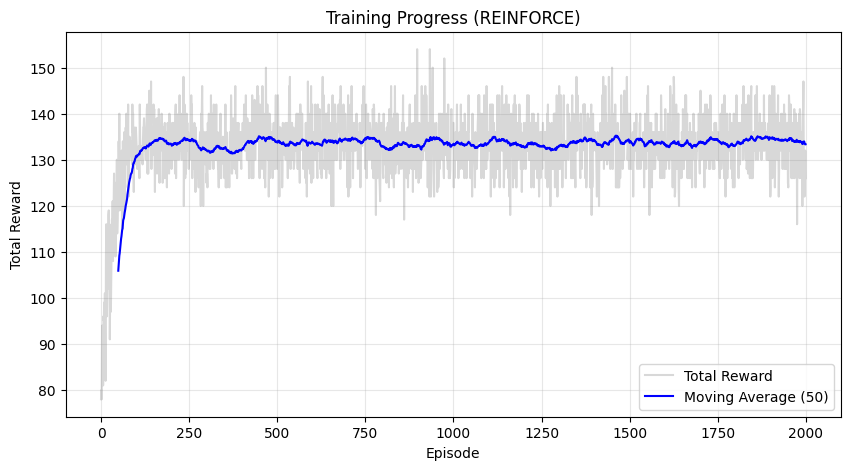


--- 7. 学習結果の考察 (獲得した方策確率) ---
State [High]:
  Wait    : 0.0000
  Search  : 1.0000
  Recharge: 0.0000
  => Most likely: Search
------------------------------
State [Low]:
  Wait    : 0.0002
  Search  : 0.0000
  Recharge: 0.9998
  => Most likely: Recharge
------------------------------


In [ ]:
# ------------------------------------------------------------------------------
# 5. 結果の可視化 & 6. 考察
# ------------------------------------------------------------------------------
if __name__ == "__main__":
    # 学習実行
    trained_policy, rewards_history = train()

    # --- 学習曲線のプロット ---
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history, label='Total Reward', alpha=0.3, color='gray')
    moving_avg = np.convolve(rewards_history, np.ones(50)/50, mode='valid')
    plt.plot(range(49, len(rewards_history)), moving_avg, label='Moving Average (50)', color='blue')
    plt.title('Training Progress (REINFORCE)')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- 獲得した方策の確認 ---
    print("\n--- 7. 学習結果の考察 (獲得した方策確率) ---")
    states = ["High", "Low"]
    actions = ["Wait", "Search", "Recharge"]

    trained_policy.eval()
    with torch.no_grad():
        for i, s_name in enumerate(states):
            state_vec = torch.zeros(2)
            state_vec[i] = 1.0
            probs = trained_policy(state_vec)

            print(f"State [{s_name}]:")
            for a_idx, a_name in enumerate(actions):
                print(f"  {a_name:<8}: {probs[a_idx]:.4f}")
            best = torch.argmax(probs).item()
            print(f"  => Most likely: {actions[best]}")
            print("-" * 30)